# Part 2 — Minimum Spanning Tree: Kruskal's & Prim's
**Algorithm Analysis and Simulation Toolkit | Term 2, SY 2025–2026**

---

### How to use this notebook
Run each cell top-to-bottom with **Shift+Enter**.

| Cell | What it does |
|------|-------------|
| **Cell 1** | Union-Find, adjacency list, Kruskal's & Prim's definitions |
| **Cell 2** | Full step-by-step simulation with exact spec output format |
| **Cell 3** | NetworkX graph visualization (original + MSTs side-by-side) |
| **Cell 4** | Automated test suite — 5 named graphs, cost agreement check |


In [1]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 1 — DATA STRUCTURES & ALGORITHM DEFINITIONS
# ═══════════════════════════════════════════════════════════════════════
%matplotlib inline
import heapq
import random
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

plt.rcParams.update({"figure.dpi": 110, "font.family": "monospace", "axes.titlesize": 12, "axes.titleweight": "bold"})
random.seed(42)

class UnionFind:
    def __init__(self, n):
        self.parent = list(range(n)); self.rank = [0] * n
    def find(self, x):
        if self.parent[x] != x: self.parent[x] = self.find(self.parent[x])
        return self.parent[x]
    def union(self, x, y):
        rx, ry = self.find(x), self.find(y)
        if rx == ry: return False
        if self.rank[rx] < self.rank[ry]: rx, ry = ry, rx
        self.parent[ry] = rx
        if self.rank[rx] == self.rank[ry]: self.rank[rx] += 1
        return True

def build_adjacency_list(vertices, edges):
    adj = defaultdict(list)
    for u, v, w in edges:
        adj[u].append((v, w)); adj[v].append((u, w))
    return dict(adj)

def print_graph_structure(vertices, edges):
    adj = build_adjacency_list(vertices, edges)
    print("  Graph Structure — Adjacency List:\n" + f"  Vertices : {vertices}\n  Edges    : {len(edges)}\n")
    for v in sorted(vertices):
        nbrs = ", ".join(f"{nb}(w={wt})" for nb, wt in sorted(adj.get(v,[])))
        print(f"    {v:>3} → [{nbrs}]")
    print("\n  Edge list (sorted by weight ascending):")
    for u, v, w in sorted(edges, key=lambda e: e[2]): print(f"    ({u}–{v}, w={w})")
    print()

def kruskal(vertices, edges, verbose=True):
    n = len(vertices); v_idx = {v: i for i, v in enumerate(vertices)}
    uf = UnionFind(n); mst = []
    sorted_edges = sorted(edges, key=lambda e: e[2])
    if verbose:
        print("═" * 62 + "\n  KRUSKAL'S ALGORITHM\n" + "═" * 62)
        print_graph_structure(vertices, edges)
        print("  Edge Selection + Cycle Detection:\n" + "─" * 62)
    step = 0
    for u, v, w in sorted_edges:
        step += 1
        if uf.union(v_idx[u], v_idx[v]):
            mst.append((u, v, w))
            if verbose: print(f"  Step {step:>2} | ({u}–{v}, w={w:>2}) → ✅ ADDED   MST so far: {[(a,b,c) for a,b,c in mst]}")
        else:
            if verbose: print(f"  Step {step:>2} | ({u}–{v}, w={w:>2}) → ❌ SKIPPED (find({u})==find({v}) → cycle)")
        if len(mst) == n - 1: break
    cost = sum(w for _, _, w in mst)
    if verbose:
        print("\n  Edges selected for MST:")
        for u, v, w in mst: print(f"    {u} -- {v}  (weight {w})")
        print(f"  Total MST Cost = {cost}\n" + "═" * 62)
    return mst, cost

def prim(vertices, edges, start=None, verbose=True):
    adj = build_adjacency_list(vertices, edges)
    start = start if start is not None else vertices[0]
    visited = set(); mst = []; heap = [(0, None, start)]
    if verbose:
        print("═" * 62 + "\n  PRIM'S ALGORITHM\n" + "═" * 62)
        print_graph_structure(vertices, edges)
        print(f"  Starting vertex : {start}\n" + "─" * 62 + "\n  Growing MST step by step:")
    step = 0
    while heap:
        w, u, v = heapq.heappop(heap)
        if v in visited: continue
        visited.add(v)
        if u is not None:
            mst.append((u, v, w)); step += 1
            if verbose: print(f"  Step {step:>2} | Add ({u}–{v}, w={w:>2})   Visited: {sorted(visited)}")
        for neighbor, weight in sorted(adj.get(v, [])):
            if neighbor not in visited: heapq.heappush(heap, (weight, v, neighbor))
    cost = sum(c for _, _, c in mst)
    if verbose:
        print("\n  Edges selected for MST:")
        for u, v, w in mst: print(f"    {u} -- {v}  (weight {w})")
        print(f"  Total MST Cost = {cost}\n" + "═" * 62)
    return mst, cost

print("✅  MST algorithms loaded\n    Data structures: Union-Find | Adjacency List | Min-Heap (heapq)")


✅  MST algorithms loaded
    Data structures: Union-Find | Adjacency List | Min-Heap (heapq)


In [2]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 2 — STEP-BY-STEP SIMULATION
# ═══════════════════════════════════════════════════════════════════════
VERTICES = [1, 2, 3, 4, 5, 6]
EDGES = [(1, 2, 4), (1, 3, 3), (2, 3, 5), (2, 4, 6), (3, 4, 7), (3, 5, 8), (4, 5, 9), (4, 6, 5), (5, 6, 6)]

k_mst, k_cost = kruskal(VERTICES, EDGES, verbose=True)
print()
p_mst, p_cost = prim(VERTICES, EDGES, start=1, verbose=True)
print()
print("─" * 40)
print(f"  Kruskal's total cost : {k_cost}\n  Prim's total cost    : {p_cost}")
print(f"  Both algorithms      : {'✅ AGREE' if k_cost == p_cost else '❌ MISMATCH'}\n" + "─" * 40)


══════════════════════════════════════════════════════════════
  KRUSKAL'S ALGORITHM
══════════════════════════════════════════════════════════════
  Graph Structure — Adjacency List:
  Vertices : [1, 2, 3, 4, 5, 6]
  Edges    : 9

      1 → [2(w=4), 3(w=3)]
      2 → [1(w=4), 3(w=5), 4(w=6)]
      3 → [1(w=3), 2(w=5), 4(w=7), 5(w=8)]
      4 → [2(w=6), 3(w=7), 5(w=9), 6(w=5)]
      5 → [3(w=8), 4(w=9), 6(w=6)]
      6 → [4(w=5), 5(w=6)]

  Edge list (sorted by weight ascending):
    (1–3, w=3)
    (1–2, w=4)
    (2–3, w=5)
    (4–6, w=5)
    (2–4, w=6)
    (5–6, w=6)
    (3–4, w=7)
    (3–5, w=8)
    (4–5, w=9)

  Edge Selection + Cycle Detection:
──────────────────────────────────────────────────────────────
  Step  1 | (1–3, w= 3) → ✅ ADDED   MST so far: [(1, 3, 3)]
  Step  2 | (1–2, w= 4) → ✅ ADDED   MST so far: [(1, 3, 3), (1, 2, 4)]
  Step  3 | (2–3, w= 5) → ❌ SKIPPED (find(2)==find(3) → cycle)
  Step  4 | (4–6, w= 5) → ✅ ADDED   MST so far: [(1, 3, 3), (1, 2, 4), (4, 6, 5)]
  St

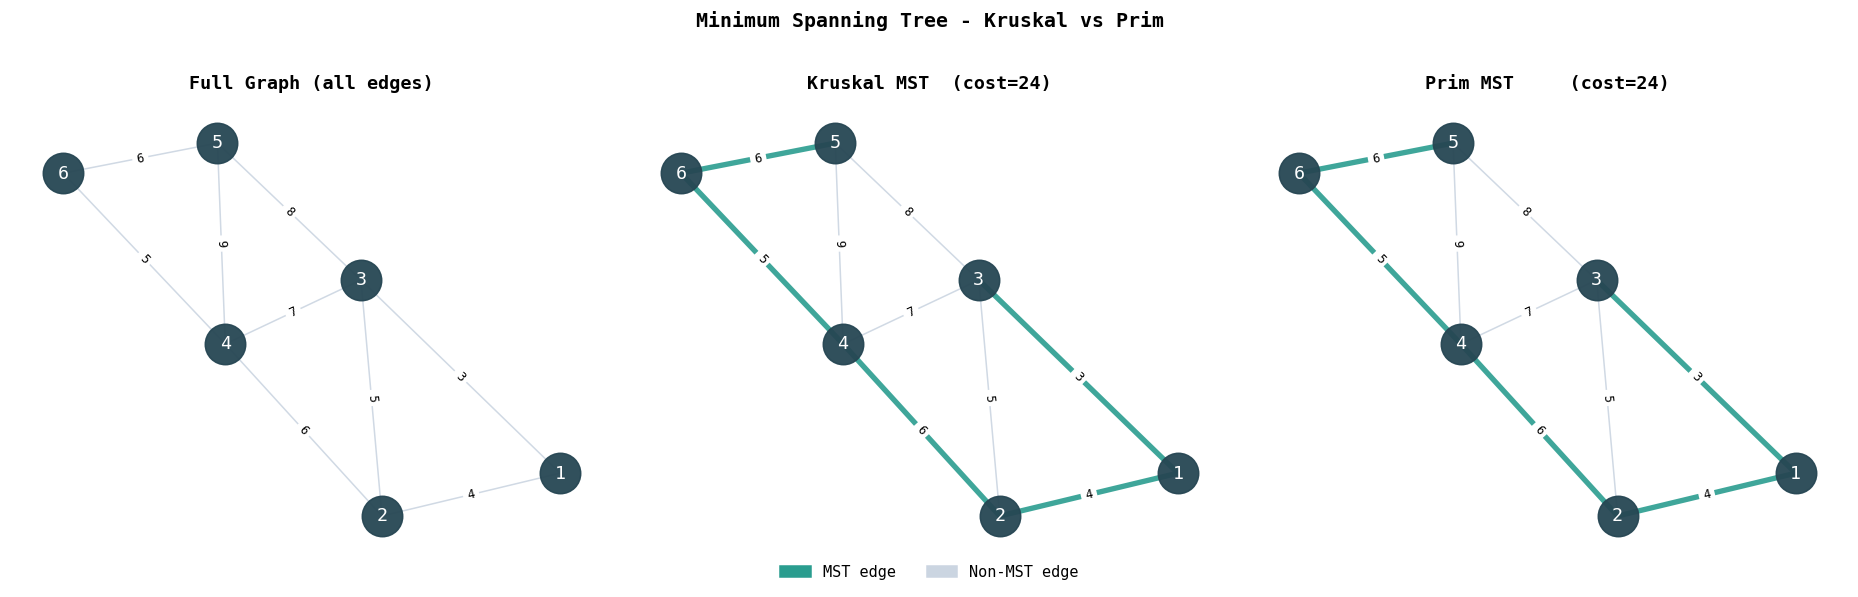

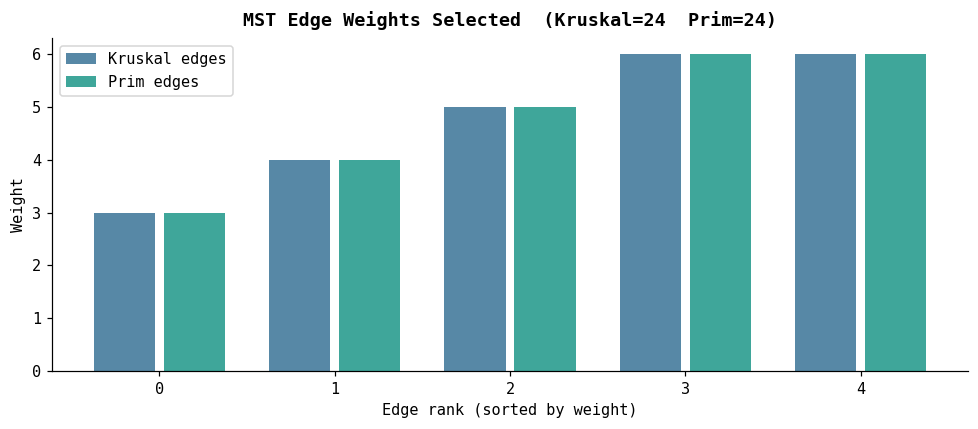

In [3]:
# =========================================================
#  CELL 3 - GRAPH VISUALIZATION (Inline rendering)
# =========================================================
def draw_graph(ax, title, vertices, edges, mst_edges=None, pos=None):
    G = nx.Graph()
    G.add_nodes_from(vertices)
    for u, v, w in edges: G.add_edge(u, v, weight=w)
    if pos is None: pos = nx.spring_layout(G, seed=42)
    mst_set = set()
    if mst_edges:
        for u, v, _ in mst_edges: mst_set.add((u, v)); mst_set.add((v, u))
    ecols = ["#2A9D8F" if (u,v) in mst_set else "#CBD5E1" for u, v in G.edges()]
    ewids = [3.5 if (u,v) in mst_set else 1.0 for u, v in G.edges()]
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color="#264653", node_size=700, alpha=0.95)
    nx.draw_networkx_labels(G, pos, ax=ax, font_color="white", font_size=12, font_family="monospace")
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color=ecols, width=ewids, alpha=0.9)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, "weight"), ax=ax, font_size=8, font_family="monospace")
    ax.set_title(title, pad=10); ax.axis("off")
    return pos

G_ref = nx.Graph(); G_ref.add_nodes_from(VERTICES)
for u, v, w in EDGES: G_ref.add_edge(u, v, weight=w)
POS = nx.spring_layout(G_ref, seed=42)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Minimum Spanning Tree - Kruskal vs Prim", fontsize=13, fontweight="bold", y=1.02)

draw_graph(axes[0], "Full Graph (all edges)", VERTICES, EDGES, pos=POS)
draw_graph(axes[1], f"Kruskal MST  (cost={k_cost})", VERTICES, EDGES, k_mst, pos=POS)
draw_graph(axes[2], f"Prim MST     (cost={p_cost})", VERTICES, EDGES, p_mst, pos=POS)

legend = [mpatches.Patch(color="#2A9D8F", label="MST edge"), mpatches.Patch(color="#CBD5E1", label="Non-MST edge")]
fig.legend(handles=legend, loc="lower center", ncol=2, frameon=False, fontsize=10, bbox_to_anchor=(0.5, -0.04))
plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(9, 4))
k_ws = sorted([w for _,_,w in k_mst]); p_ws = sorted([w for _,_,w in p_mst])
xs = range(max(len(k_ws), len(p_ws)))
ax2.bar([x-0.2 for x in xs[:len(k_ws)]], k_ws, width=0.35, color="#457B9D", label="Kruskal edges", alpha=0.9)
ax2.bar([x+0.2 for x in xs[:len(p_ws)]], p_ws, width=0.35, color="#2A9D8F", label="Prim edges", alpha=0.9)
ax2.set_xlabel("Edge rank (sorted by weight)"); ax2.set_ylabel("Weight")
ax2.set_title(f"MST Edge Weights Selected  (Kruskal={k_cost}  Prim={p_cost})", pad=8)
ax2.legend(); ax2.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()


In [4]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 4 — AUTOMATED TEST SUITE
# ═══════════════════════════════════════════════════════════════════════
TEST_GRAPHS = [
    ("Simple triangle", [1,2,3], [(1,2,1),(2,3,2),(1,3,10)], 3),
    ("Linear chain", [1,2,3,4], [(1,2,5),(2,3,3),(3,4,4)], 12),
    ("All equal weights", [1,2,3,4], [(1,2,1),(2,3,1),(3,4,1),(1,4,1),(1,3,1),(2,4,1)], 3),
    ("Spec sample graph (6 vertices)", [1,2,3,4,5,6], [(1,2,4),(1,3,3),(2,3,5),(2,4,6),(3,4,7),(3,5,8),(4,5,9),(4,6,5),(5,6,6)], 24),
    ("Classic 5-vertex", [1,2,3,4,5], [(1,2,3),(2,4,5),(4,5,6),(1,3,4),(3,5,7)], 18),
]
print("=" * 70 + "\n  MST TEST SUITE — Kruskal vs Prim cost agreement\n" + "=" * 70)
print(f"  {'Test':<38} {'Kruskal':>8} {'Prim':>6} {'Expected':>9}  {'Pass?'}\n" + "─" * 70)
total = passed = 0
for name, verts, edges, expected in TEST_GRAPHS:
    total += 1
    try:
        _, kc = kruskal(verts, edges, verbose=False)
        _, pc = prim(verts, edges, verbose=False)
        ok = (kc == pc == expected)
        if ok: passed += 1
        print(f"  {name:<38} {kc:>8} {pc:>6} {expected:>9}  {'✅' if ok else '❌'}")
    except Exception as e: print(f"  {name:<38} ERROR: {e}")
print("─" * 70 + f"\n  Results: {passed}/{total} tests passed")
if passed == total: print("  🎉 Both algorithms verified correct on all graphs!")
print("=" * 70)


  MST TEST SUITE — Kruskal vs Prim cost agreement
  Test                                    Kruskal   Prim  Expected  Pass?
──────────────────────────────────────────────────────────────────────
  Simple triangle                               3      3         3  ✅
  Linear chain                                 12     12        12  ✅
  All equal weights                             3      3         3  ✅
  Spec sample graph (6 vertices)               24     24        24  ✅
  Classic 5-vertex                             18     18        18  ✅
──────────────────────────────────────────────────────────────────────
  Results: 5/5 tests passed
  🎉 Both algorithms verified correct on all graphs!
